# Objetivo

El objetivo de este análisis es segmentar las interacciones proteicas en grupos basados en la fuerza de su _combined_score_, lo cual es una técnica común para identificar distintos niveles de confianza biológica de forma automatizada.

In [8]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Inicializar sesión
spark = SparkSession.builder \
    .appName("MLlib_Protein_Clustering") \
    .getOrCreate()

In [10]:
# 1. Carga de datos
df = spark.read.option("header", "true").option("sep", " ").option("inferSchema", "true") \
    .csv("../data/9606.protein.links.v12.0.txt.gz")

In [11]:
# 2. Preparación de características (Feature Engineering)
# MLlib requiere que todas las variables de entrada estén en una sola columna de tipo vector
assembler = VectorAssembler(inputCols=["combined_score"], outputCol="features")
df_vector = assembler.transform(df)

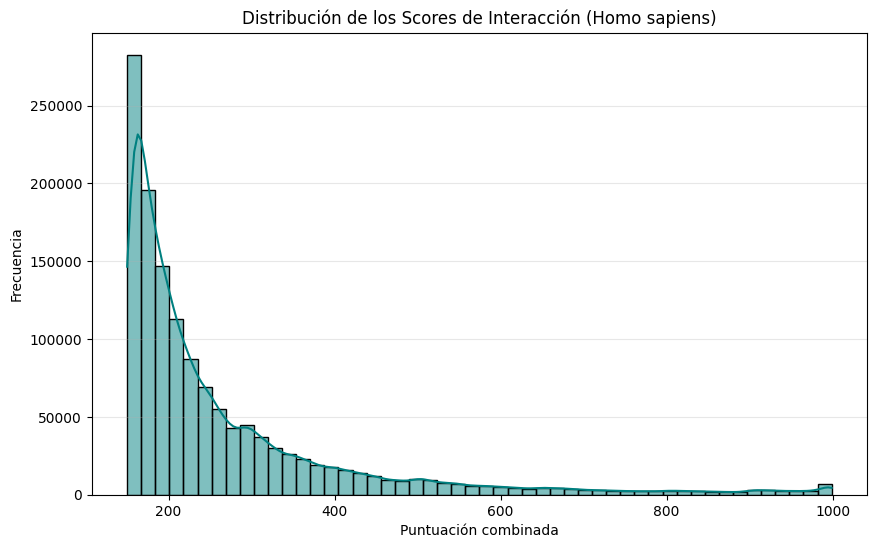

In [22]:
# Grafica de la distribución de los datos
# Tomamos una muestra aleatoria para no saturar la memoria de la gráfica
sample_pd = df.select("combined_score").sample(False, 0.1).toPandas()

plt.figure(figsize=(10, 6))
sns.histplot(sample_pd['combined_score'], bins=50, kde=True, color='teal')
plt.title('Distribución de los Scores de Interacción (Homo sapiens)')
plt.xlabel('Puntuación combinada')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [12]:
# Normalización (Opcional en 1D, pero buena práctica en MLlib)
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures")
df_scaled = scaler.fit(df_vector).transform(df_vector)

In [13]:
# 3. Entrenamiento del Modelo K-Means
# Definimos k=3 (para intentar agrupar en Confianza Baja, Media y Alta)
kmeans = KMeans(featuresCol="scaledFeatures", k=3, seed=42)
model = kmeans.fit(df_scaled)

26/04/13 11:47:43 WARN MemoryStore: Not enough space to cache rdd_44_0 in memory! (computed 348.8 MiB so far)
26/04/13 11:47:43 WARN BlockManager: Persisting block rdd_44_0 to disk instead.
26/04/13 11:48:01 WARN MemoryStore: Not enough space to cache rdd_44_0 in memory! (computed 348.8 MiB so far)
26/04/13 11:48:05 WARN MemoryStore: Not enough space to cache rdd_44_0 in memory! (computed 348.8 MiB so far)
26/04/13 11:48:09 WARN MemoryStore: Not enough space to cache rdd_44_0 in memory! (computed 348.8 MiB so far)
26/04/13 11:48:09 WARN MemoryStore: Not enough space to cache rdd_44_0 in memory! (computed 98.1 MiB so far)
26/04/13 11:48:09 WARN MemoryStore: Not enough space to cache rdd_48_0 in memory! (computed 4.0 MiB so far)
26/04/13 11:48:09 WARN BlockManager: Persisting block rdd_48_0 to disk instead.
26/04/13 11:48:18 WARN MemoryStore: Not enough space to cache rdd_44_0 in memory! (computed 348.8 MiB so far)
26/04/13 11:48:18 WARN MemoryStore: Not enough space to cache rdd_48_0 in

In [14]:
# 4. Predicción y Resultados
predictions = model.transform(df_scaled)

In [15]:
# 5. Evaluación del modelo
evaluator = ClusteringEvaluator()
silhouette = evaluator.evaluate(predictions)

print(f"Coeficiente de Silhouette: {silhouette:.4f}") # Mide qué tan cerca está cada punto a su propio cluster
print("Centros de los clusters (normalizados):")
for center in model.clusterCenters():
    print(center)

Coeficiente de Silhouette: 0.8237
Centros de los clusters (normalizados):
[2.46126872]
[1.24577973]
[4.91015949]


In [16]:
# Muestra de resultados
predictions.select("protein1", "protein2", "combined_score", "prediction").show(10)

+--------------------+--------------------+--------------+----------+
|            protein1|            protein2|combined_score|prediction|
+--------------------+--------------------+--------------+----------+
|9606.ENSP00000000233|9606.ENSP00000356607|           173|         1|
|9606.ENSP00000000233|9606.ENSP00000427567|           154|         1|
|9606.ENSP00000000233|9606.ENSP00000253413|           151|         1|
|9606.ENSP00000000233|9606.ENSP00000493357|           471|         0|
|9606.ENSP00000000233|9606.ENSP00000324127|           201|         1|
|9606.ENSP00000000233|9606.ENSP00000325266|           180|         1|
|9606.ENSP00000000233|9606.ENSP00000320935|           181|         1|
|9606.ENSP00000000233|9606.ENSP00000371175|           594|         2|
|9606.ENSP00000000233|9606.ENSP00000480364|           154|         1|
|9606.ENSP00000000233|9606.ENSP00000388107|           161|         1|
+--------------------+--------------------+--------------+----------+
only showing top 10 

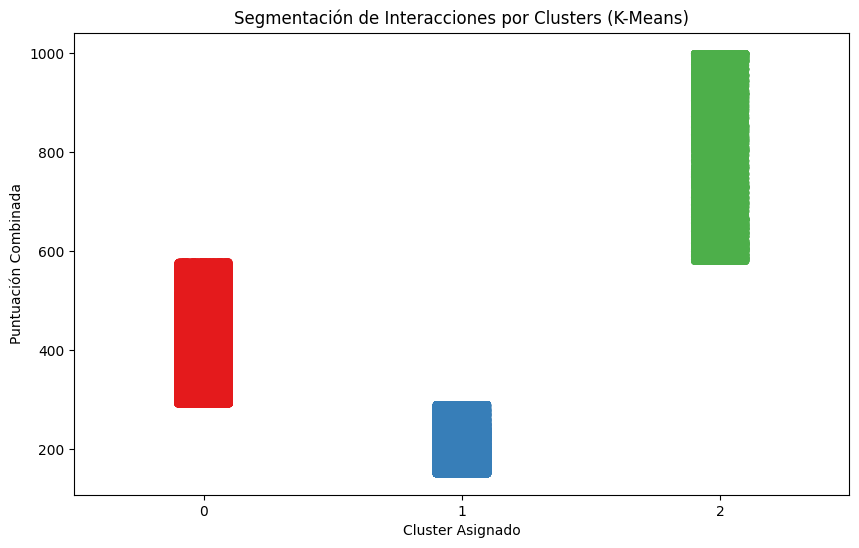

In [26]:
pdf_clusters = predictions.select("combined_score", "prediction").sample(False, 0.05).toPandas()

plt.figure(figsize=(10, 6))
sns.stripplot(x='prediction', y='combined_score', data=pdf_clusters, jitter=True, hue='prediction', legend=False, palette='Set1')
plt.title('Segmentación de Interacciones por Clusters (K-Means)')
plt.xlabel('Cluster Asignado')
plt.ylabel('Puntuación Combinada')
plt.show()